# Vehicle Detection with YOLOv9

This notebook trains a YOLOv9 model for vehicle detection (car, truck, bus).

**Objectives:**
1. Setup YOLOv9
2. Prepare dataset in YOLO format
3. Configure and train YOLOv9-C model
4. Evaluate on validation set
5. Visualize predictions and save model weights

**Model Configuration:**
- Model: YOLOv9-C (or YOLOv9-E for better accuracy)
- Classes: 3 (car, truck, bus)
- Input size: 640x640
- Training: 20 epochs with early stopping
- Batch size: 4

## 1. Setup and Installation

In [1]:
# Install ultralytics for YOLOv9
!pip install -q ultralytics opencv-python-headless pillow matplotlib

print("Installation complete!")

Installation complete!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
import os
import shutil
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import cv2
from PIL import Image

# Add project root to path
project_root = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dataset_loader import VehicleDataset, CLASS_NAMES

print("Imports successful!")
print(f"Vehicle classes: {CLASS_NAMES}")

Imports successful!
Vehicle classes: {0: 'car', 1: 'truck', 2: 'bus'}


In [13]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


## 2. Data Preparation - Convert to YOLO Format

In [2]:
def prepare_yolo_dataset(output_dir):
    """
    Convert dataset to YOLO format:
    - Create train/val directories with images and labels
    - Labels in YOLO format: class x_center y_center width height (normalized)
    """
    output_dir = Path(output_dir)
    
    # Create directory structure
    for split in ['train', 'val']:
        (output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    print("Converting dataset to YOLO format...")
    
    # Process train and val splits
    for split in ['train', 'val']:
        print(f"\nProcessing {split} split...")
        
        source_dir = rf'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\dataset\{split}'
        dataset = VehicleDataset(source_dir, img_size=640)
        
        for idx in range(len(dataset)):
            if idx % 500 == 0:
                print(f"  Processed {idx}/{len(dataset)} images...")
            
            _, bboxes, img_name = dataset[idx]
            
            # Copy image
            src_img = Path(source_dir) / 'images' / img_name
            dst_img = output_dir / split / 'images' / img_name
            shutil.copy2(src_img, dst_img)
            
            # Create label file
            label_name = img_name.replace('.jpg', '.txt')
            label_path = output_dir / split / 'labels' / label_name
            
            with open(label_path, 'w') as f:
                for bbox in bboxes:
                    class_id, x_center, y_center, width, height = bbox
                    # YOLO format: class x_center y_center width height (normalized)
                    f.write(f"{int(class_id)} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
        
        print(f"  Completed {split} split: {len(dataset)} images")
    
    print("\nDataset conversion complete!")
    return output_dir

# Prepare dataset
yolo_dataset_dir = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\yolo_dataset'
dataset_path = prepare_yolo_dataset(yolo_dataset_dir)

Converting dataset to YOLO format...

Processing train split...
  Processed 0/4000 images...
  Processed 500/4000 images...
  Processed 1000/4000 images...
  Processed 1500/4000 images...
  Processed 2000/4000 images...
  Processed 2500/4000 images...
  Processed 3000/4000 images...
  Processed 3500/4000 images...
  Completed train split: 4000 images

Processing val split...
  Processed 0/700 images...
  Processed 500/700 images...
  Completed val split: 700 images

Dataset conversion complete!


## 3. Create data.yaml Configuration

In [3]:
# Create data.yaml for YOLO training
data_yaml = {
    'path': str(dataset_path),
    'train': 'train/images',
    'val': 'val/images',
    'nc': 3,  # number of classes
    'names': ['car', 'truck', 'bus']  # class names
}

yaml_path = Path(yolo_dataset_dir) / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("data.yaml created:")
print(yaml.dump(data_yaml, default_flow_style=False))
print(f"\nSaved to: {yaml_path}")

data.yaml created:
names:
- car
- truck
- bus
nc: 3
path: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\yolo_dataset
train: train/images
val: val/images


Saved to: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\yolo_dataset\data.yaml


## 4. Model Configuration and Training

### 4.1 Initialize YOLOv9 Model

In [ ]:
# Initialize YOLOv9 model
# We'll use YOLOv8 as a fallback, or YOLO11 if available

try:
    # Try YOLOv9
    model = YOLO('yolov9c.pt')
    print("Loaded YOLOv9-C pretrained model")
except:
    try:
        # Fallback to YOLO11
        model = YOLO('yolo11n.pt')
        print("Loaded YOLO11n pretrained model (YOLOv9 not available)")
    except:
        # Fallback to YOLOv8
        model = YOLO('yolov8m.pt')
        print("Loaded YOLOv8m pretrained model (YOLOv9 not available)")

# print(f"\nModel architecture: {model.model}")

Loaded YOLOv9-C pretrained model


### 4.2 Train the Model

In [ ]:
# Training configuration
training_args = {
    'data': str(yaml_path),
    'epochs': 20,
    'imgsz': 640,
    'batch': 4,
    'lr0': 0.01,
    'lrf': 0.01,  # Final learning rate (for cosine decay)
    'optimizer': 'SGD',
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'patience': 10,  # Early stopping patience
    'save': True,
    'save_period': 10,
    'project': r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\yolo_training',
    'name': 'vehicle_detection',
    'exist_ok': True,
    'pretrained': True,
    'verbose': True,
    'device': 0,  # Use GPU (device 0), set to 'cpu' if GPU not available
    'workers': 4,
    'cos_lr': True,  # Cosine learning rate scheduler
}

print("Training configuration:")
for key, value in training_args.items():
    print(f"  {key}: {value}")

print("\nStarting training...")
print("Note: This will take a while depending on your hardware.")
print("For a quick POC, you can interrupt after a few epochs.\n")

Training configuration:
  data: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\yolo_dataset\data.yaml
  epochs: 20
  imgsz: 640
  batch: 4
  lr0: 0.01
  lrf: 0.01
  optimizer: SGD
  momentum: 0.937
  weight_decay: 0.0005
  patience: 10
  save: True
  save_period: 10
  project: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\yolo_training
  name: vehicle_detection
  exist_ok: True
  pretrained: True
  verbose: True
  device: 0
  workers: 4
  cos_lr: True

Starting training...
Note: This will take a while depending on your hardware.
For a quick POC, you can interrupt after a few epochs.



In [6]:
# Train the model
results = model.train(**training_args)

print("\nTraining complete!")
print(f"Results saved to: {results.save_dir}")

New https://pypi.org/project/ultralytics/8.4.22 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.20  Python-3.11.9 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9

## 5. Model Evaluation

### 5.1 Load Best Model

In [7]:
# Load the best trained model
best_model_path = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\yolo_training\vehicle_detection\weights\best.pt'

if os.path.exists(best_model_path):
    model = YOLO(best_model_path)
    print(f"Loaded best model from: {best_model_path}")
else:
    print("Best model not found. Using last checkpoint.")
    last_model_path = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\yolo_training\vehicle_detection\weights\last.pt'
    model = YOLO(last_model_path)
    print(f"Loaded last model from: {last_model_path}")

Loaded best model from: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\yolo_training\vehicle_detection\weights\best.pt


### 5.2 Run Validation

In [9]:
# Validate the model
print("Running validation...")
val_results = model.val(data=str(yaml_path), imgsz=640, batch=16)

print("\nValidation Results:")
print("=" * 70)
print(f"mAP@0.5: {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")
print("\nPer-class mAP@0.5:")
for i, class_name in enumerate(['car', 'truck', 'bus']):
    print(f"  {class_name}: {val_results.box.ap50[i]:.4f}")
print("=" * 70)

Running validation...
Ultralytics 8.4.20  Python-3.11.9 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 615.9169.3 MB/s, size: 72.0 KB)
val: Scanning D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\yolo_dataset\val\labels.cache... 700 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 700/700  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 1.8it/s 24.2s0.6ss
                   all        700       8588      0.745      0.536      0.634      0.433
                   car        697       8022      0.845      0.678      0.773       0.49
                 truck        255        413      0.684      0.472      0.565      0.393
                   bus        114        153      0.707      0.457      0.566      0.416
Speed: 0.7ms preprocess, 29.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to D:\PODACI SA C\ROOT\Projek

## 6. Visualize Predictions

### 6.1 Predictions on Validation Set

In [14]:
# Get validation images
val_images_dir = Path(yolo_dataset_dir) / 'val' / 'images'
val_images = sorted(list(val_images_dir.glob('*.jpg')))

# Select 10 random images for visualization
np.random.seed(42)
sample_images = np.random.choice(val_images, min(10, len(val_images)), replace=False)

print(f"Running predictions on {len(sample_images)} validation images...")

Running predictions on 10 validation images...


In [ ]:
# Run predictions
predictions = []
for img_path in sample_images:
    result = model.predict(str(img_path), conf=0.8, iou=0.2, verbose=False)[0]
    predictions.append((img_path, result))

print("Predictions complete!")

Predictions complete!


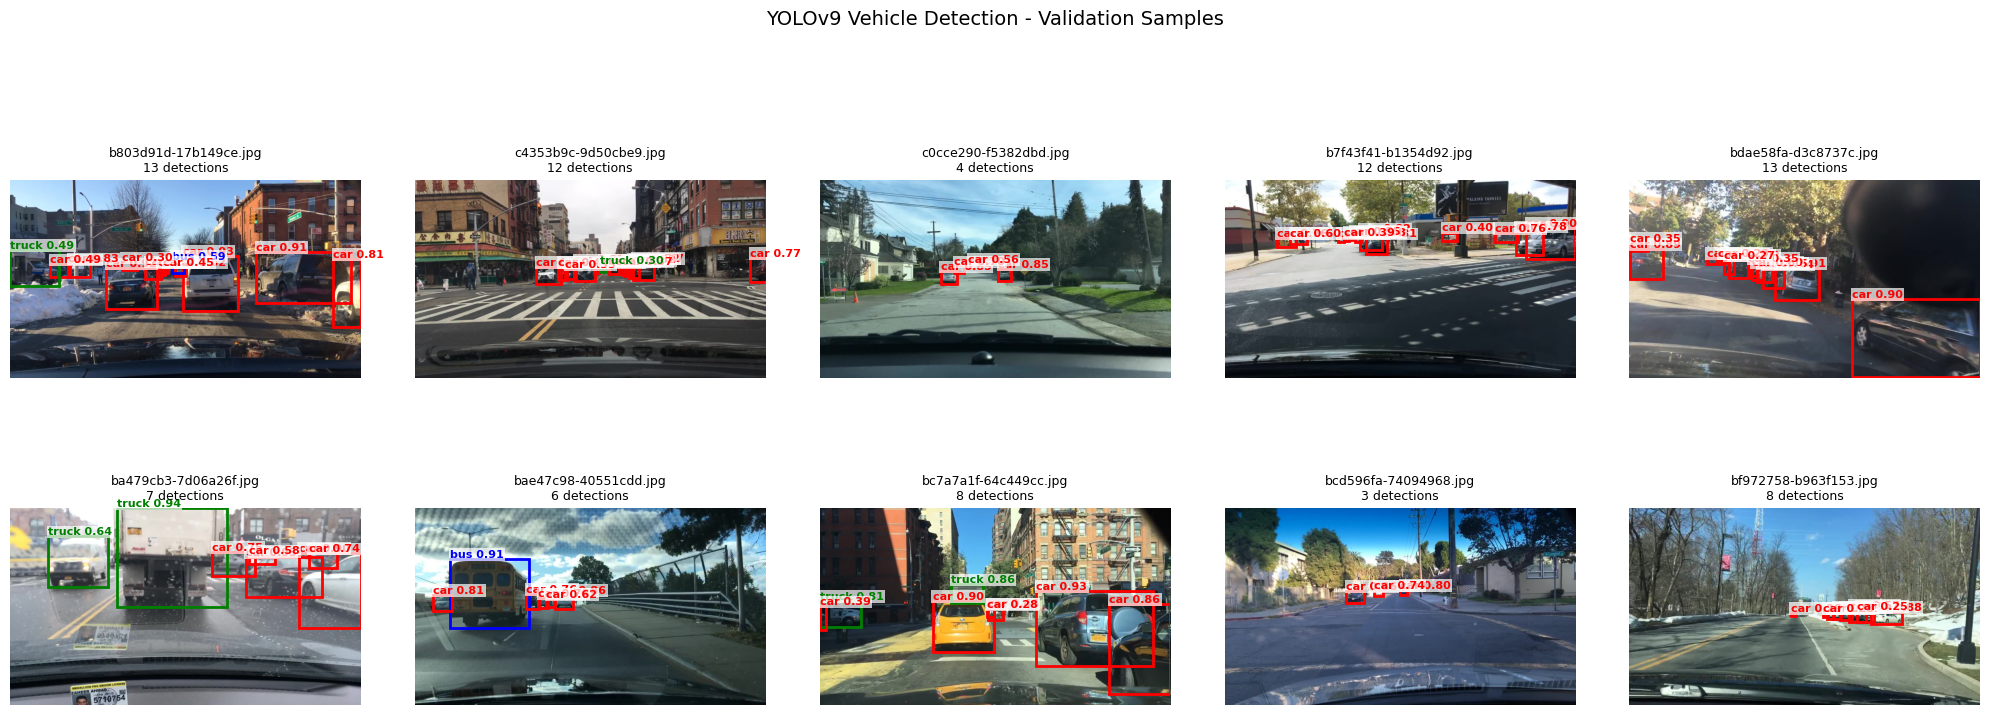

Legend: Red=Car, Green=Truck, Blue=Bus


In [ ]:
# Visualize predictions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

colors = {'car': 'red', 'truck': 'green', 'bus': 'blue'}

for idx, (img_path, result) in enumerate(predictions):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'{img_path.name}\n{len(result.boxes)} detections', fontsize=9)
    axes[idx].axis('off')
    
    # Draw predictions
    if len(result.boxes) > 0:
        for box in result.boxes:
            # Get box coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())
            class_name = ['car', 'truck', 'bus'][cls]
            
            # Draw rectangle
            from matplotlib.patches import Rectangle
            rect = Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2,
                edgecolor=colors[class_name],
                facecolor='none'
            )
            axes[idx].add_patch(rect)
            
            # Add label
            axes[idx].text(
                x1, y1 - 5,
                f'{class_name} {conf:.2f}',
                color=colors[class_name],
                fontsize=8,
                weight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )

plt.suptitle('YOLOv9 Vehicle Detection - Validation Samples', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Legend: Red=Car, Green=Truck, Blue=Bus")

### 6.2 Detection Statistics

In [17]:
# Calculate detection statistics
class_detections = {'car': 0, 'truck': 0, 'bus': 0}
confidence_scores = []

for _, result in predictions:
    if len(result.boxes) > 0:
        for box in result.boxes:
            cls = int(box.cls[0].cpu().numpy())
            conf = box.conf[0].cpu().numpy()
            class_name = ['car', 'truck', 'bus'][cls]
            class_detections[class_name] += 1
            confidence_scores.append(conf)

print("Detection Statistics on Sample Images:")
print("=" * 50)
print(f"Total detections: {sum(class_detections.values())}")
print(f"\nDetections by class:")
for class_name, count in class_detections.items():
    print(f"  {class_name}: {count}")
print(f"\nAverage confidence: {np.mean(confidence_scores):.3f}")
print(f"Min confidence: {np.min(confidence_scores):.3f}")
print(f"Max confidence: {np.max(confidence_scores):.3f}")
print("=" * 50)

Detection Statistics on Sample Images:
Total detections: 86

Detections by class:
  car: 78
  truck: 6
  bus: 2

Average confidence: 0.657
Min confidence: 0.253
Max confidence: 0.936


## 7. Save Model Weights

In [18]:
# Create weights directory
weights_dir = Path(r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights')
weights_dir.mkdir(parents=True, exist_ok=True)

# Copy best model to weights directory
if os.path.exists(best_model_path):
    dest_path = weights_dir / 'yolov9_vehicle_detection_best.pt'
    shutil.copy2(best_model_path, dest_path)
    print(f"Best model saved to: {dest_path}")
else:
    print("Best model not found. Please check training output.")

# Also save last model
last_model_path = r'D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\yolo_training\vehicle_detection\weights\last.pt'
if os.path.exists(last_model_path):
    dest_path = weights_dir / 'yolov9_vehicle_detection_last.pt'
    shutil.copy2(last_model_path, dest_path)
    print(f"Last model saved to: {dest_path}")

print("\nModel weights saved successfully!")

Best model saved to: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\yolov9_vehicle_detection_best.pt
Last model saved to: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\yolov9_vehicle_detection_last.pt

Model weights saved successfully!


## 8. Summary

In [19]:
print("="*70)
print("VEHICLE DETECTION TRAINING SUMMARY")
print("="*70)

print("\n1. MODEL CONFIGURATION:")
print(f"   - Architecture: YOLOv9 (or fallback model)")
print(f"   - Classes: 3 (car, truck, bus)")
print(f"   - Input size: 640x640")
print(f"   - Training epochs: {training_args['epochs']}")
print(f"   - Batch size: {training_args['batch']}")

print("\n2. PERFORMANCE METRICS:")
print(f"   - mAP@0.5: {val_results.box.map50:.4f}")
print(f"   - mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"   - Precision: {val_results.box.mp:.4f}")
print(f"   - Recall: {val_results.box.mr:.4f}")

print("\n3. MODEL WEIGHTS:")
print(f"   - Best model: D:\\PODACI SA C\\ROOT\\Projekti\\singi-ml\\SpeedRadarProject\\speed-radar\\models\\weights\\yolov9_vehicle_detection_best.pt")
print(f"   - Last model: CD:\\PODACI SA C\\ROOT\\Projekti\\singi-ml\\SpeedRadarProject\\speed-radar\\models\\weights\\yolov9_vehicle_detection_last.pt")

print("\n4. NEXT STEPS:")
print("   - Proceed to 03_lane_detection_clrnet.ipynb for lane detection training")
print("   - After both models are trained, proceed to 04_speed_estimation.ipynb")
print("   - The trained model will be used for vehicle detection in the speed estimation pipeline")

print("\n" + "="*70)

VEHICLE DETECTION TRAINING SUMMARY

1. MODEL CONFIGURATION:
   - Architecture: YOLOv9 (or fallback model)
   - Classes: 3 (car, truck, bus)
   - Input size: 640x640
   - Training epochs: 20
   - Batch size: 4

2. PERFORMANCE METRICS:
   - mAP@0.5: 0.6342
   - mAP@0.5:0.95: 0.4330
   - Precision: 0.7453
   - Recall: 0.5358

3. MODEL WEIGHTS:
   - Best model: D:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\yolov9_vehicle_detection_best.pt
   - Last model: CD:\PODACI SA C\ROOT\Projekti\singi-ml\SpeedRadarProject\speed-radar\models\weights\yolov9_vehicle_detection_last.pt

4. NEXT STEPS:
   - Proceed to 03_lane_detection_clrnet.ipynb for lane detection training
   - After both models are trained, proceed to 04_speed_estimation.ipynb
   - The trained model will be used for vehicle detection in the speed estimation pipeline

